# 01 — Exploratory Data Analysis

**SubscribeIQ — Subscription Intelligence & Retention Engine**

Every query in this notebook runs against the PostgreSQL star schema built in Phase 1
(`dim_customer`, `dim_service`, `dim_contract`, `fact_subscription`), not the raw CSV.
Aggregations are pushed down into SQL wherever possible, so the warehouse does the work
and pandas only receives small result sets.

Each chart has a short **business reading** under it: what it means for a retention team,
not only what it shows.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sqlalchemy import text

sys.path.insert(0, str(Path.cwd().parent))
from src.db_connection import get_engine

engine = get_engine()

def sql(query: str) -> pd.DataFrame:
    """Run a query against the SubscribeIQ warehouse and return a DataFrame."""
    return pd.read_sql(text(query), engine)

# Chart styling: recessive axes/grid, thin marks, text in ink colours (not series colours)
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
BLUE, ORANGE = "#2a78d6", "#eb6834"   # categorical slots 1 and 2 (retained / churned)
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "text.color": INK,
    "xtick.color": INK_2, "ytick.color": INK_2, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.axisbelow": True, "axes.spines.top": False,
    "axes.spines.right": False, "axes.titleweight": "bold", "axes.titlesize": 12,
    "axes.titlelocation": "left", "font.size": 10, "figure.dpi": 110,
})

def label_bars(ax, bars, fmt="{:.1f}%", extra=None):
    """Direct-label bar ends; optional second line (e.g. sample size) in muted ink."""
    for i, b in enumerate(bars):
        txt = fmt.format(b.get_height())
        if extra is not None:
            txt += f"\n{extra[i]}"
        ax.annotate(txt, (b.get_x() + b.get_width() / 2, b.get_height()),
                    xytext=(0, 4), textcoords="offset points", ha="center", va="bottom",
                    fontsize=9, color=INK)

sql("SELECT COUNT(*) AS customers FROM fact_subscription")

,customers
0,7043


## 1. Overall churn rate and distribution

,status,customers,monthly_revenue,pct_customers,pct_revenue
0,Retained,5174,316985.75,73.46,69.5
1,Churned,1869,139130.85,26.54,30.5


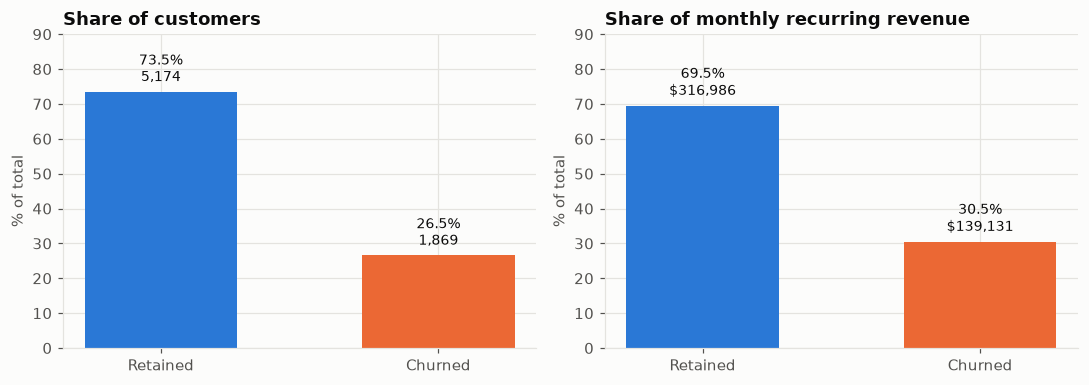

In [2]:
overall = sql("""
    SELECT CASE WHEN churn THEN 'Churned' ELSE 'Retained' END AS status,
           COUNT(*)                         AS customers,
           ROUND(SUM(monthly_charges), 2)   AS monthly_revenue
    FROM fact_subscription
    GROUP BY churn
    ORDER BY churn
""")
overall["pct_customers"] = (100 * overall.customers / overall.customers.sum()).round(2)
overall["pct_revenue"] = (100 * overall.monthly_revenue / overall.monthly_revenue.sum()).round(2)
display(overall)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, col, title in [(axes[0], "customers", "Share of customers"),
                       (axes[1], "monthly_revenue", "Share of monthly recurring revenue")]:
    share = 100 * overall[col] / overall[col].sum()
    bars = ax.bar(overall.status, share, color=[BLUE, ORANGE], width=0.55)
    labels = (overall[col].map("{:,.0f}".format) if col == "customers"
              else overall[col].map("${:,.0f}".format))
    label_bars(ax, bars, extra=list(labels))
    ax.set_title(title); ax.set_ylim(0, 90); ax.set_ylabel("% of total")
fig.tight_layout(); plt.show()

**Business reading.** About 1 in 4 customers (26.5%, 1,869 of 7,043) churned, but they took
**30.5% of monthly recurring revenue** with them ($139k of $456k per month). Churners are
disproportionately *higher-paying* customers, so churn costs more in revenue than the headcount
suggests. The class imbalance (~3:1) also matters for Phase 4: accuracy alone would be a
misleading model metric, since predicting "no churn" for everyone already scores 73.5%.

## 2. Churn rate by contract type

,contract_type,customers,churn_rate_pct,avg_monthly_charges
0,Month-to-month,3875,42.7,66.40
1,One year,1473,11.3,65.05
2,Two year,1695,2.8,60.77


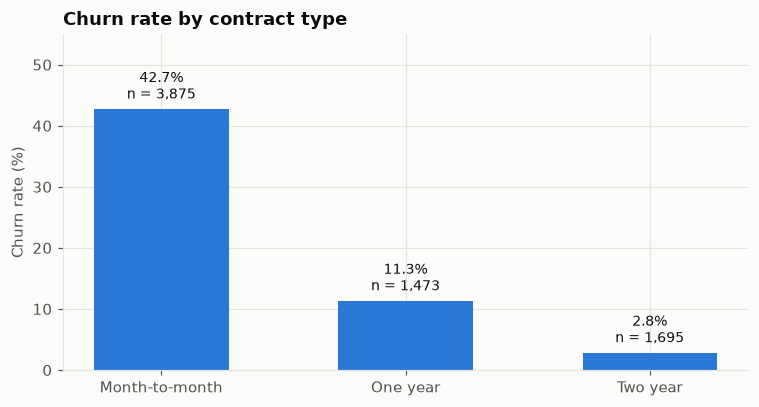

In [3]:
contract = sql("""
    SELECT k.contract_type,
           COUNT(*)                              AS customers,
           ROUND(100 * AVG(f.churn::int), 1)     AS churn_rate_pct,
           ROUND(AVG(f.monthly_charges), 2)      AS avg_monthly_charges
    FROM fact_subscription f
    JOIN dim_contract k USING (customer_id)
    GROUP BY k.contract_type
    ORDER BY churn_rate_pct DESC
""")
display(contract)

fig, ax = plt.subplots(figsize=(7, 3.8))
bars = ax.bar(contract.contract_type, contract.churn_rate_pct, color=BLUE, width=0.55)
label_bars(ax, bars, extra=[f"n = {n:,}" for n in contract.customers])
ax.set_title("Churn rate by contract type"); ax.set_ylabel("Churn rate (%)"); ax.set_ylim(0, 55)
fig.tight_layout(); plt.show()

**Business reading.** Contract type is the single sharpest divider in the data:
month-to-month customers churn at **42.7%**, about 4× one-year (11.3%) and 15× two-year (2.8%)
customers. Month-to-month is also the *majority* of the base (3,875 customers, 55%), so most
of the churn problem sits here. The obvious lever is converting month-to-month customers to
annual terms. Part of this gap is self-selection (committed customers pick long contracts),
so the real effect of a conversion campaign would be smaller than 42.7% → 11.3% and should be
tested, not assumed.

## 3. Churn rate by tenure bucket

,tenure_bucket,customers,churned,churn_rate_pct,share_of_all_churners_pct
0,0-12 mo,2186,1037,47.4,55.5
1,13-24 mo,1024,294,28.7,15.7
2,25-48 mo,1594,325,20.4,17.4
3,49-72 mo,2239,213,9.5,11.4


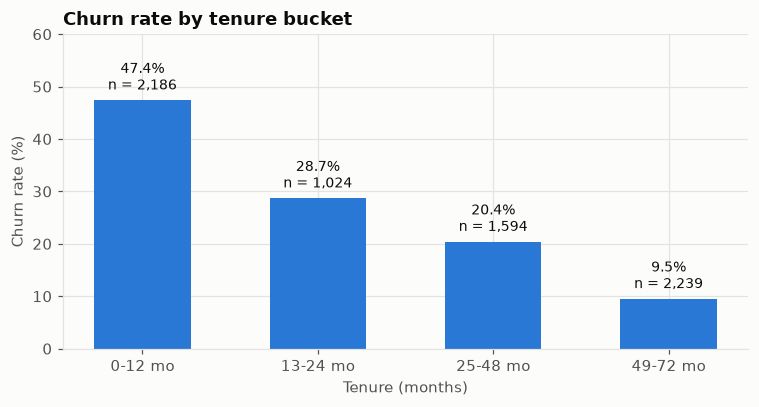

In [4]:
tenure = sql("""
    SELECT CASE WHEN tenure_months <= 12 THEN '0-12 mo'
                WHEN tenure_months <= 24 THEN '13-24 mo'
                WHEN tenure_months <= 48 THEN '25-48 mo'
                ELSE '49-72 mo' END            AS tenure_bucket,
           COUNT(*)                            AS customers,
           SUM(churn::int)                     AS churned,
           ROUND(100 * AVG(churn::int), 1)     AS churn_rate_pct
    FROM fact_subscription
    GROUP BY 1
    ORDER BY MIN(tenure_months)
""")
tenure["share_of_all_churners_pct"] = (100 * tenure.churned / tenure.churned.sum()).round(1)
display(tenure)

fig, ax = plt.subplots(figsize=(7, 3.8))
bars = ax.bar(tenure.tenure_bucket, tenure.churn_rate_pct, color=BLUE, width=0.55)
label_bars(ax, bars, extra=[f"n = {n:,}" for n in tenure.customers])
ax.set_title("Churn rate by tenure bucket"); ax.set_ylabel("Churn rate (%)"); ax.set_ylim(0, 60)
ax.set_xlabel("Tenure (months)")
fig.tight_layout(); plt.show()

**Business reading.** Risk is front-loaded: **47.4%** of customers in their first year churn,
and that first-year group accounts for **55.5% of all churners** (1,037 of 1,869). After year
one the rate falls steadily to 9.5% for customers past four years. Onboarding and the first
12 months are where retention spend works hardest; a customer who survives year one is far
less likely to leave. (Tenure is observed at a single snapshot, so these are churn rates *of
customers currently at that tenure*, not a true survival curve.)

## 4. Monthly charges distribution by churn status

,status,mean,median,avg_tenure_months
0,Retained,61.27,64.425,37.6
1,Churned,74.44,79.650,18.0


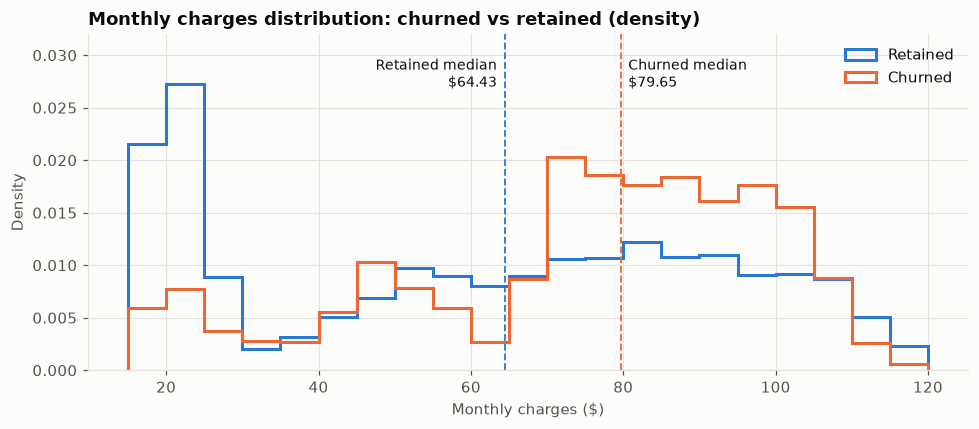

In [5]:
charges = sql("""
    SELECT monthly_charges::float AS monthly_charges, churn
    FROM fact_subscription
""")
summary = sql("""
    SELECT CASE WHEN churn THEN 'Churned' ELSE 'Retained' END AS status,
           ROUND(AVG(monthly_charges), 2)                                   AS mean,
           PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY monthly_charges)     AS median,
           ROUND(AVG(tenure_months), 1)                                     AS avg_tenure_months
    FROM fact_subscription GROUP BY churn ORDER BY churn
""")
display(summary)

fig, ax = plt.subplots(figsize=(9, 4))
bins = range(15, 125, 5)
for flag, color, name, side in [(False, BLUE, "Retained", "right"), (True, ORANGE, "Churned", "left")]:
    vals = charges.loc[charges.churn == flag, "monthly_charges"]
    ax.hist(vals, bins=bins, density=True, histtype="step", linewidth=2, color=color, label=name)
    med = vals.median()
    ax.axvline(med, color=color, linestyle="--", linewidth=1.2)
    ax.annotate(f"{name} median\n${med:.2f}", (med, 0.027), ha=side,
                xytext=(-5 if side == "right" else 5, 0), textcoords="offset points",
                fontsize=9, color=INK)
ax.set_ylim(0, 0.032)
ax.set_title("Monthly charges distribution: churned vs retained (density)")
ax.set_xlabel("Monthly charges ($)"); ax.set_ylabel("Density")
ax.legend(frameon=False, loc="upper right")
fig.tight_layout(); plt.show()

**Business reading.** Churners pay more: median **$79.65** vs **$64.43** for retained customers.
The retained distribution has a large spike at ~$20 (phone-only customers, who rarely leave),
while churners are concentrated in the $70–$105 band, which is mostly fiber-optic internet
(see section 5). High price alone doesn't cause churn. The more likely reading is that
premium-priced customers who don't perceive matching value are the ones leaving. Pricing and
value-perception on the fiber tier is worth investigating before discounting across the board.

## 5. Service adoption vs churn

Two cuts are needed here. The six add-on services only exist for internet customers, and the
"No internet service" group churns at just 7.4%, so including them would distort every
comparison. And add-on buyers skew towards long contracts, which could make an add-on *look*
protective when the contract is doing the work. So each add-on is compared **(a)** across all
internet customers and **(b)** within month-to-month internet customers only.

,internet_service,customers,churn_rate_pct,avg_monthly_charges
0,Fiber optic,3096,41.9,91.50
1,DSL,2421,19.0,58.10
2,No,1526,7.4,21.08


,churn_all_internet_without,churn_all_internet_with,churn_month_to_month_without,churn_month_to_month_with,gap_all_internet,gap_month_to_month
addon,,,,,,
online_security,41.8,14.6,51.0,29.6,27.2,21.4
tech_support,41.6,15.2,50.4,30.7,26.4,19.7
online_backup,39.9,21.5,50.3,38.1,18.4,12.2
device_protection,39.1,22.5,47.6,43.6,16.6,4.0
streaming_tv,33.5,30.1,43.8,50.6,3.4,-6.8
streaming_movies,33.7,29.9,44.0,50.3,3.8,-6.3


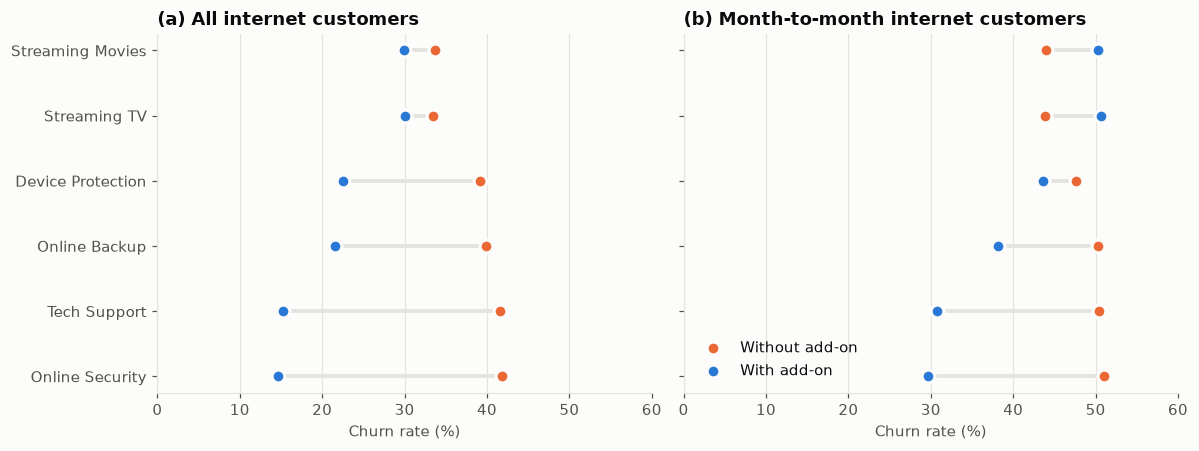

In [6]:
internet = sql("""
    SELECT s.internet_service,
           COUNT(*)                            AS customers,
           ROUND(100 * AVG(f.churn::int), 1)   AS churn_rate_pct,
           ROUND(AVG(f.monthly_charges), 2)    AS avg_monthly_charges
    FROM fact_subscription f JOIN dim_service s USING (customer_id)
    GROUP BY 1 ORDER BY churn_rate_pct DESC
""")
display(internet)

ADDONS = ["online_security", "tech_support", "online_backup",
          "device_protection", "streaming_tv", "streaming_movies"]
parts = []
for col in ADDONS:
    parts.append(f"""
        SELECT '{col}' AS addon, s.{col} = 'Yes' AS has_addon,
               COUNT(*) AS customers,
               ROUND(100 * AVG(f.churn::int), 1) AS churn_all_internet,
               ROUND(100 * AVG(f.churn::int) FILTER (WHERE k.contract_type = 'Month-to-month'), 1)
                   AS churn_month_to_month
        FROM fact_subscription f
        JOIN dim_service s USING (customer_id)
        JOIN dim_contract k USING (customer_id)
        WHERE s.internet_service <> 'No'
        GROUP BY 2""")
addons = sql(" UNION ALL ".join(parts))
wide = addons.pivot(index="addon", columns="has_addon",
                    values=["churn_all_internet", "churn_month_to_month"])
wide.columns = [f"{m}_{'with' if h else 'without'}" for m, h in wide.columns]
wide["gap_all_internet"] = wide.churn_all_internet_without - wide.churn_all_internet_with
wide["gap_month_to_month"] = wide.churn_month_to_month_without - wide.churn_month_to_month_with
wide = wide.loc[ADDONS]
display(wide)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
names = ["Online Security", "Tech Support", "Online Backup",
         "Device Protection", "Streaming TV", "Streaming Movies"]
y = range(len(ADDONS))
for ax, metric, title in [(axes[0], "churn_all_internet", "(a) All internet customers"),
                          (axes[1], "churn_month_to_month", "(b) Month-to-month internet customers")]:
    w, wo = wide[f"{metric}_with"], wide[f"{metric}_without"]
    ax.hlines(y, w, wo, color=GRID, linewidth=2.5, zorder=1)
    ax.scatter(wo, y, s=70, color=ORANGE, zorder=2, label="Without add-on",
               edgecolor=SURFACE, linewidth=2)
    ax.scatter(w, y, s=70, color=BLUE, zorder=3, label="With add-on",
               edgecolor=SURFACE, linewidth=2)
    ax.set_yticks(list(y)); ax.set_yticklabels(names); ax.invert_yaxis()
    ax.set_xlim(0, 60); ax.set_xlabel("Churn rate (%)"); ax.set_title(title)
    ax.grid(axis="y", visible=False)
axes[1].legend(frameon=False, loc="lower left")
fig.tight_layout(); plt.show()

**Business reading.**
- **Fiber optic is the riskiest product:** 41.9% churn vs 19.0% for DSL, despite (or because
  of) its ~$92 average bill. Among month-to-month customers, fiber churn reaches 54.6%.
- **Online Security and Tech Support are the protective add-ons, and the effect survives the
  contract control.** Within month-to-month internet customers, churn is ~51% without either and
  ~30% with it, a ~20-point gap that is *not* explained by contract length. These are
  "support/safety" services that plausibly raise switching cost and trust.
- **Online Backup's effect shrinks** (≈18 → 12 points) and **Device Protection's almost vanishes**
  (≈17 → 4 points) once contract is held fixed, so most of their raw correlation came from
  contract mix.
- **Streaming TV/Movies do not retain customers.** Within month-to-month customers, streaming
  subscribers churn *more* (≈50% vs 44%), likely because streaming bundles sit on high fiber bills.

Implication: bundling Security + Tech Support into at-risk month-to-month fiber plans is a
concrete retention offer to test, while streaming add-ons shouldn't be pitched as retention tools.
These are correlations; a controlled offer test would confirm causality.

## 6. Payment method vs churn rate

,payment_method,customers,churn_rate_pct
0,Electronic check,2365,45.3
1,Mailed check,1612,19.1
2,Bank transfer (automatic),1544,16.7
3,Credit card (automatic),1522,15.2


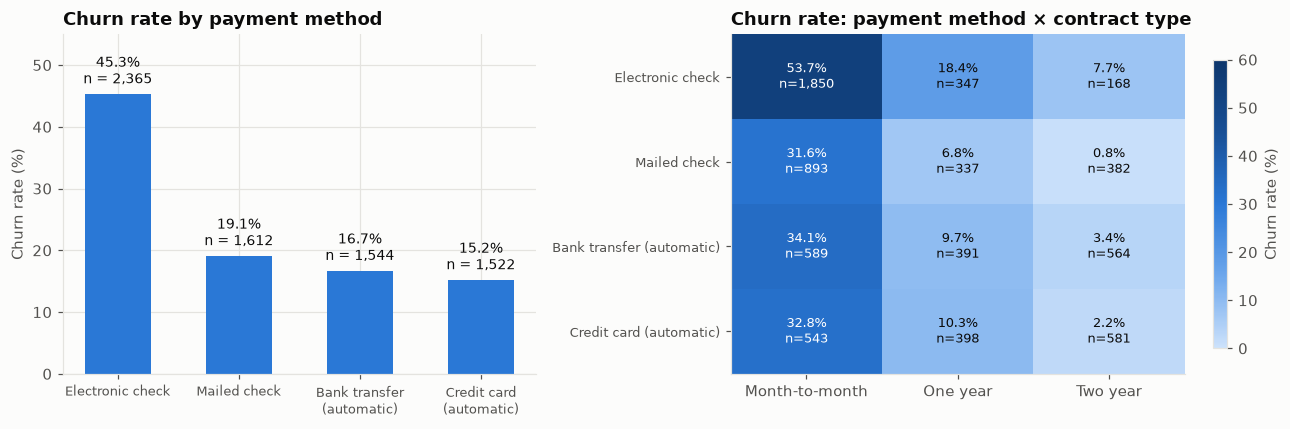

In [7]:
payment = sql("""
    SELECT k.payment_method,
           COUNT(*)                            AS customers,
           ROUND(100 * AVG(f.churn::int), 1)   AS churn_rate_pct
    FROM fact_subscription f JOIN dim_contract k USING (customer_id)
    GROUP BY 1 ORDER BY churn_rate_pct DESC
""")
display(payment)

grid = sql("""
    SELECT k.contract_type, k.payment_method,
           COUNT(*) AS customers, ROUND(100 * AVG(f.churn::int), 1) AS churn_rate_pct
    FROM fact_subscription f JOIN dim_contract k USING (customer_id)
    GROUP BY 1, 2
""")
heat = grid.pivot(index="payment_method", columns="contract_type", values="churn_rate_pct")
heat = heat.loc[payment.payment_method, ["Month-to-month", "One year", "Two year"]]
counts = grid.pivot(index="payment_method", columns="contract_type", values="customers").loc[heat.index, heat.columns]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1, 1.2]})
ax = axes[0]
short = [m.replace(" (automatic)", "\n(automatic)") for m in payment.payment_method]
bars = ax.bar(short, payment.churn_rate_pct, color=BLUE, width=0.55)
label_bars(ax, bars, extra=[f"n = {n:,}" for n in payment.customers])
ax.set_title("Churn rate by payment method"); ax.set_ylabel("Churn rate (%)"); ax.set_ylim(0, 55)
ax.tick_params(axis="x", labelsize=8.5)

ax = axes[1]
from matplotlib.colors import LinearSegmentedColormap
blues = LinearSegmentedColormap.from_list("seq_blue", ["#cde2fb", "#6da7ec", "#2a78d6", "#184f95", "#0d366b"])
im = ax.imshow(heat.values, cmap=blues, vmin=0, vmax=60, aspect="auto")
ax.set_xticks(range(3)); ax.set_xticklabels(heat.columns)
ax.set_yticks(range(len(heat))); ax.set_yticklabels(heat.index, fontsize=8.5)
ax.grid(False)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        ax.text(j, i, f"{v:.1f}%\nn={counts.values[i, j]:,}", ha="center", va="center",
                fontsize=8.5, color="white" if v > 25 else INK)
ax.set_title("Churn rate: payment method × contract type")
fig.colorbar(im, ax=ax, label="Churn rate (%)", shrink=0.85)
fig.tight_layout(); plt.show()

**Business reading.** Electronic-check payers churn at **45.3%**, versus 15–19% for every other
method. The heatmap shows this is *partly* a contract effect (48% of month-to-month customers pay
by e-check vs 10% of two-year customers), but not entirely: e-check still has the highest churn
inside every contract type (53.7% in month-to-month, 18.4% in one-year). Automatic payment
methods sit at the bottom in every column. Nudging customers to auto-pay (card or bank transfer)
is a cheap, low-risk intervention to test; the worst cell, month-to-month + e-check (1,850
customers, 53.7% churn), is the priority audience.

## Key findings

| # | Finding | Evidence | Implication |
|---|---------|----------|-------------|
| 1 | Churn hits revenue harder than headcount | 26.5% of customers, 30.5% of MRR | Prioritise by revenue, not customer count |
| 2 | Contract type is the strongest single signal | 42.7% month-to-month vs 2.8% two-year | Test annual-contract conversion offers |
| 3 | The first year is the danger zone | 47.4% churn in 0–12 mo; 55.5% of all churners | Invest in onboarding / first-year check-ins |
| 4 | Fiber optic customers are high-risk | 41.9% vs 19.0% DSL; 54.6% within month-to-month | Investigate fiber value perception & pricing |
| 5 | Security & Tech Support are protective even controlling for contract | ~51% → ~30% within month-to-month | Bundle these into retention offers |
| 6 | Streaming add-ons are not retentive | Higher churn with streaming within month-to-month | Don't use streaming as a retention lever |
| 7 | Electronic check is a risk marker in every contract type | 45.3% overall; 53.7% in month-to-month | Nudge toward auto-pay |

**Carry-forward to Phase 4:** these variables (contract, tenure, internet type, security/support
add-ons, payment method) are strong churn-model candidates, and several are correlated with each
other (contract ↔ payment method ↔ tenure). Tree models handle that naturally; for logistic
regression, coefficients on correlated features need careful interpretation.